# Bank Customer Churn — Full Pipeline
**Project:** Classifier with Honest Metrics
**Dataset:** Bank Customer Churn (Kaggle)

This single notebook covers EDA → Baseline (Logistic Regression) → Improved (Random Forest) → Error Analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, precision_score,
                             recall_score)

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('../data/Churn_Modelling.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
print(f'Shape after dropping IDs: {df.shape}')

Shape after dropping IDs: (10000, 11)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## 2. Exploratory Data Analysis

### Target Distribution — Class Imbalance

Churn rate: 20.4%
Exited
0    7963
1    2037
Name: count, dtype: int64


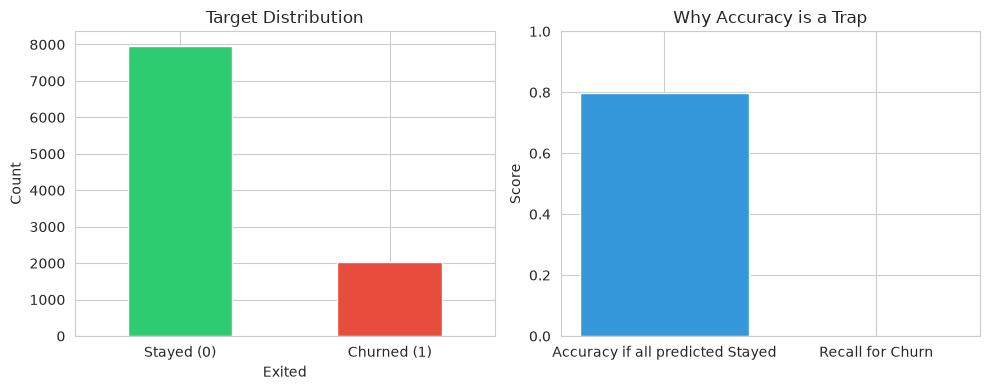

In [6]:
churn_counts = df['Exited'].value_counts()
print(f'Churn rate: {df["Exited"].mean():.1%}')
print(churn_counts)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
ax[0].set_ylabel('Count')
ax[0].set_title('Target Distribution')

dummy_acc = 1 - df['Exited'].mean()
dummy_recall_churn = 0
ax[1].bar(['Accuracy if all predicted Stayed', 'Recall for Churn'],
        [dummy_acc, dummy_recall_churn], color=['#3498db', '#e74c3c'])
ax[1].set_ylim(0, 1)
ax[1].set_ylabel('Score')
ax[1].set_title('Why Accuracy is a Trap')
plt.tight_layout()
plt.show()

### Geography Analysis

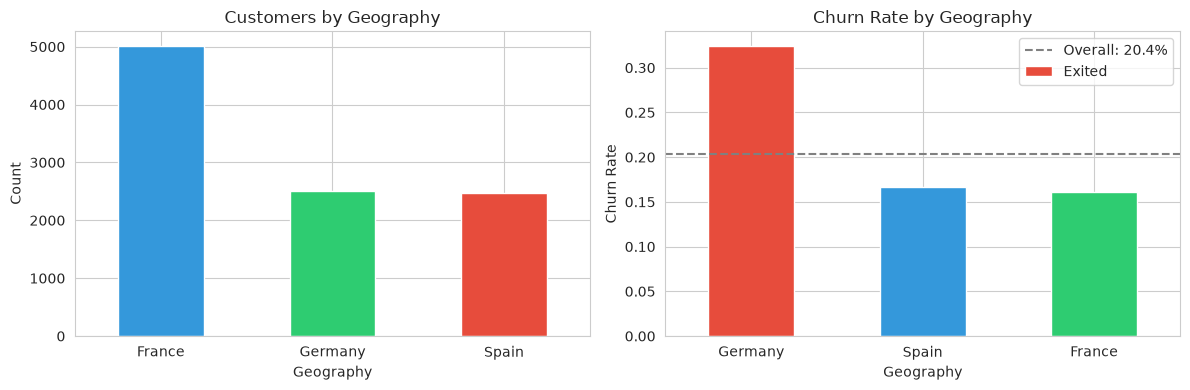

Germany churn rate: 32.4%
France churn rate: 16.2%
Spain churn rate: 16.7%


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

geo_counts = df['Geography'].value_counts()
geo_counts.plot(kind='bar', ax=ax[0], color=['#3498db', '#2ecc71', '#e74c3c'])
ax[0].set_title('Customers by Geography')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(geo_counts.index, rotation=0)

geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo_churn.plot(kind='bar', ax=ax[1], color=['#e74c3c', '#3498db', '#2ecc71'])
ax[1].set_title('Churn Rate by Geography')
ax[1].set_ylabel('Churn Rate')
ax[1].axhline(df['Exited'].mean(), color='gray', linestyle='--',
            label=f'Overall: {df["Exited"].mean():.1%}')
ax[1].legend()
ax[1].set_xticklabels(geo_churn.index, rotation=0)
plt.tight_layout()
plt.show()

print(f'Germany churn rate: {geo_churn["Germany"]:.1%}')
print(f'France churn rate: {geo_churn["France"]:.1%}')
print(f'Spain churn rate: {geo_churn["Spain"]:.1%}')

### Numerical Features vs Churn

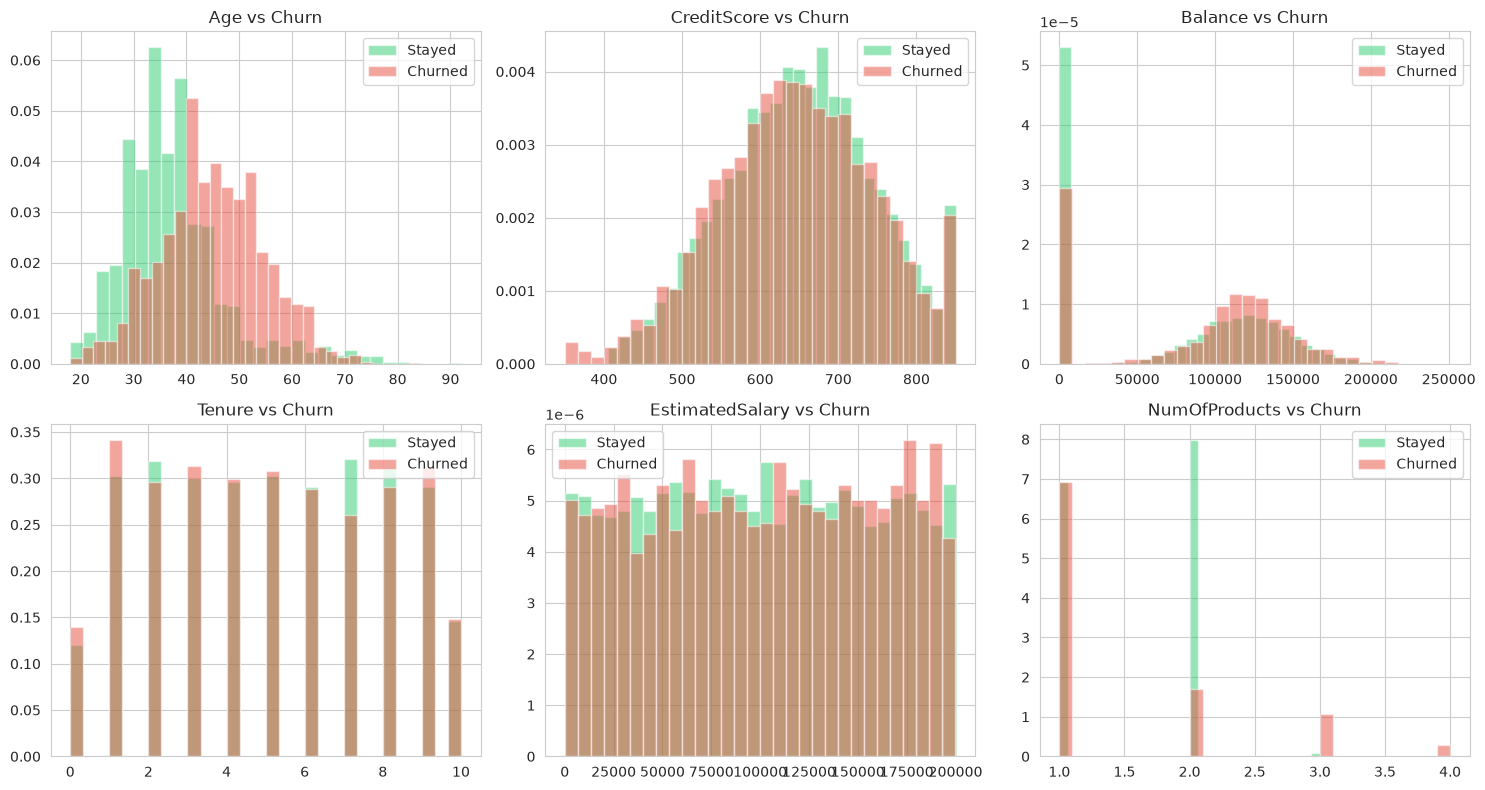

In [8]:
num_cols = ['Age', 'CreditScore', 'Balance', 'Tenure', 'EstimatedSalary', 'NumOfProducts']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Churned')]:
        subset = df[df['Exited'] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(f'{col} vs Churn')
    axes[i].legend()

plt.tight_layout()
plt.show()

### Categorical Features vs Churn

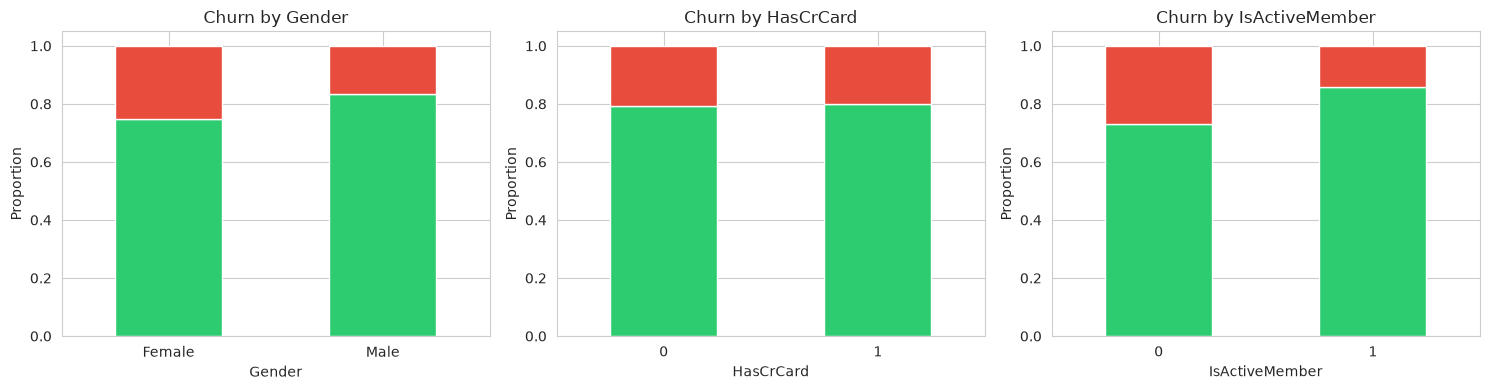

In [9]:
cat_cols_eda = ['Gender', 'HasCrCard', 'IsActiveMember']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_cols_eda):
    ct = pd.crosstab(df[col], df['Exited'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], stacked=True, color=['#2ecc71', '#e74c3c'], legend=False)
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Age Analysis

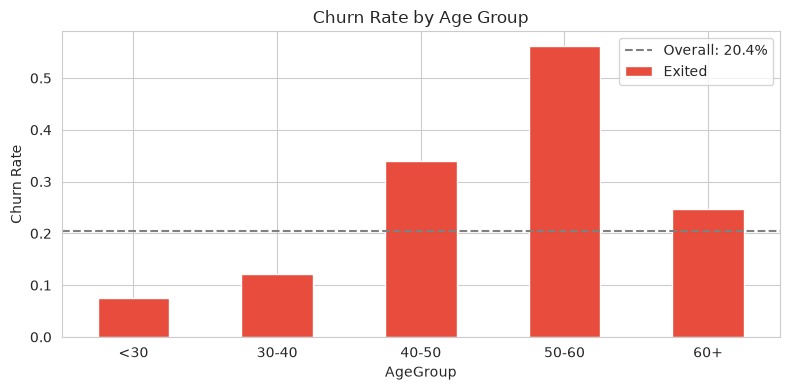

AgeGroup
<30      0.075203
30-40    0.120872
40-50    0.339655
50-60    0.562108
60+      0.247845
Name: Exited, dtype: float64


In [10]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                      labels=['<30', '30-40', '40-50', '50-60', '60+'])
age_churn = df.groupby('AgeGroup', observed=False)['Exited'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
age_churn.plot(kind='bar', ax=ax, color='#e74c3c')
ax.set_title('Churn Rate by Age Group')
ax.set_ylabel('Churn Rate')
ax.axhline(df['Exited'].mean(), color='gray', linestyle='--',
          label=f'Overall: {df["Exited"].mean():.1%}')
ax.legend()
ax.set_xticklabels(age_churn.index, rotation=0)
plt.tight_layout()
plt.show()
print(age_churn)

### Key EDA Insights

In [11]:
churn_rate = df['Exited'].mean()
print('=== KEY INSIGHTS ===')
print(f'1. CLASS IMBALANCE: {churn_rate:.1%} churn rate. A dummy model '
      f'predicting all stayed gets {1-churn_rate:.1%} accuracy but 0% recall.')
print('2. GEOGRAPHY: Germany has ~2x the churn rate of France/Spain.')
print('3. AGE: Churn rate spikes after age 50.')
print('4. ACTIVE MEMBERSHIP: Inactive members churn at much higher rates.')

=== KEY INSIGHTS ===
1. CLASS IMBALANCE: 20.4% churn rate. A dummy model predicting all stayed gets 79.6% accuracy but 0% recall.
2. GEOGRAPHY: Germany has ~2x the churn rate of France/Spain.
3. AGE: Churn rate spikes after age 50.
4. ACTIVE MEMBERSHIP: Inactive members churn at much higher rates.


## 3. Train/Validation/Test Split (60/20/20)

In [12]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train: {X_train.shape[0]} samples ({y_train.mean():.1%} churn)')
print(f'Val:   {X_val.shape[0]} samples ({y_val.mean():.1%} churn)')
print(f'Test:  {X_test.shape[0]} samples ({y_test.mean():.1%} churn)')

Train: 6000 samples (20.4% churn)
Val:   2000 samples (20.4% churn)
Test:  2000 samples (20.3% churn)


## 4. Preprocessing Pipeline

In [13]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
cat_cols = ['Geography', 'Gender']
bin_cols = ['HasCrCard', 'IsActiveMember']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ('bin', 'passthrough', bin_cols)
])

print ('preprocessor defined, features extracted after fit')

preprocessor defined, features extracted after fit


## 5. Baseline: Logistic Regression

### Train Baseline

In [14]:
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression trained')
joblib.dump(lr_pipeline, '../outputs/lr_model.pkl')
joblib.dump(preprocessor, '../outputs/preprocessor.pkl')

Logistic Regression trained


['../outputs/preprocessor.pkl']

### Baseline Metrics

=== Logistic Regression Test Metrics ===
              precision    recall  f1-score   support

      Stayed       0.83      0.97      0.89      1593
     Churned       0.62      0.20      0.30       407

    accuracy                           0.81      2000
   macro avg       0.72      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC: 0.770
PR-AUC:  0.490


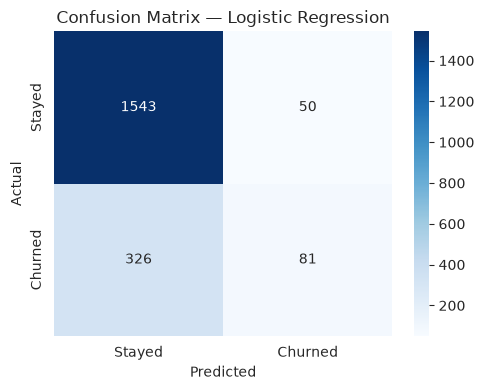

In [15]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print('=== Logistic Regression Test Metrics ===')
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_lr):.3f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

### Baseline ROC & PR Curves

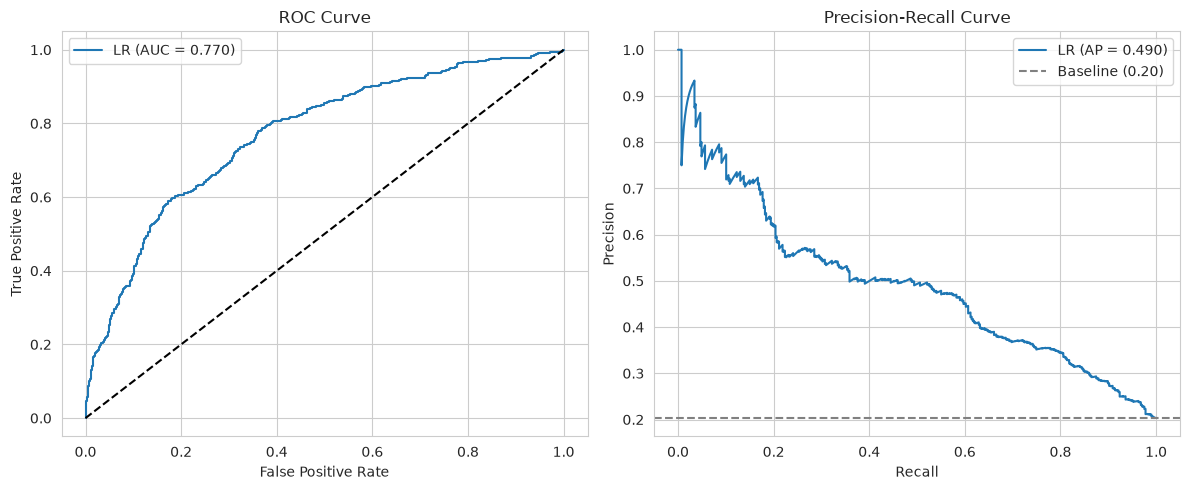

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
ax[0].plot(fpr, tpr, label=f'LR (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend()

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ax[1].plot(recall_lr, precision_lr, label=f'LR (AP = {average_precision_score(y_test, y_prob_lr):.3f})')
ax[1].axhline(y_test.mean(), color='gray', linestyle='--',
            label=f'Baseline ({y_test.mean():.2f})')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend()
plt.tight_layout()
plt.show()

### Baseline Summary

Logistic Regression gives a floor to beat. Key weakness: low recall on churners (20%).

## 6. Improved Model: Random Forest with Balanced Class Weight

### Preprocess (fit on train, transform all)

In [17]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Rebuild feature names after fit
cat_names = []
for i, col in enumerate(cat_cols):
    cats = preprocessor.named_transformers_['cat'].categories_[i]
    cat_names.extend([f'{col}_{c}' for c in cats[1:]])
feature_names = num_cols + cat_names + bin_cols
print('Features:', feature_names)

Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard', 'IsActiveMember']


### Train Random Forest

In [18]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42,
                            n_estimators=200, max_depth=10)
rf.fit(X_train_proc, y_train)
print('Random Forest trained')
joblib.dump(rf, '../outputs/rf_model.pkl')

Random Forest trained


['../outputs/rf_model.pkl']

### RF Metrics (default threshold=0.5)

=== Random Forest (default 0.5 threshold) ===
              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89      1593
     Churned       0.57      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC: 0.858
PR-AUC:  0.684


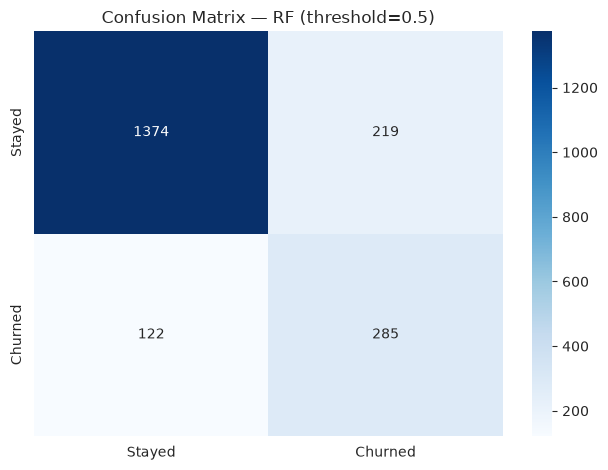

In [19]:
y_pred_rf = rf.predict(X_test_proc)
y_prob_rf = rf.predict_proba(X_test_proc)[:, 1]

print('=== Random Forest (default 0.5 threshold) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_rf):.3f}')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — RF (threshold=0.5)')
plt.tight_layout()
plt.show()

### Threshold Tuning — Optimize on Validation Set

Best threshold: 0.554
Best F1 on val: 0.640


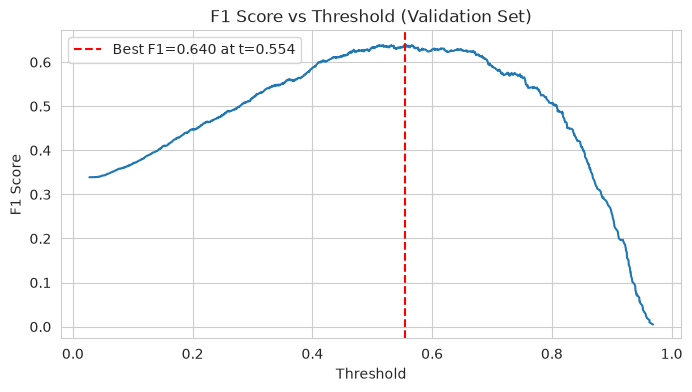

In [20]:
val_prob = rf.predict_proba(X_val_proc)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_prob)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.3f}')
print(f'Best F1 on val: {best_f1:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores)
ax.axvline(best_threshold, color='red', linestyle='--',
          label=f'Best F1={best_f1:.3f} at t={best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Threshold (Validation Set)')
ax.legend()
plt.show()

### RF Metrics (tuned threshold)

=== Random Forest (tuned threshold=0.554) ===
              precision    recall  f1-score   support

      Stayed       0.91      0.90      0.90      1593
     Churned       0.62      0.64      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



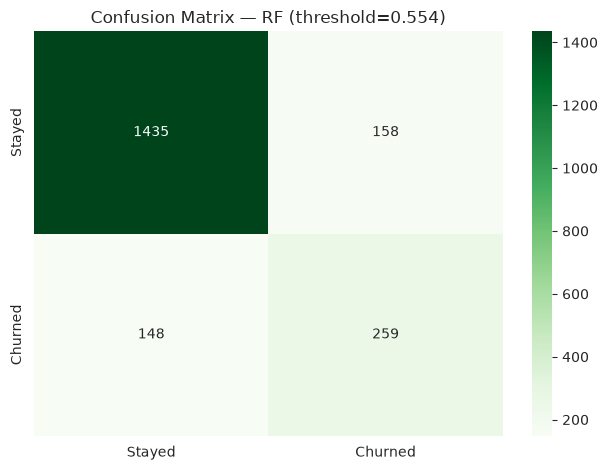

In [21]:
y_pred_tuned = (y_prob_rf >= best_threshold).astype(int)

print(f'=== Random Forest (tuned threshold={best_threshold:.3f}) ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Churned']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix — RF (threshold={best_threshold:.3f})')
plt.tight_layout()
plt.show()

### Feature Importance

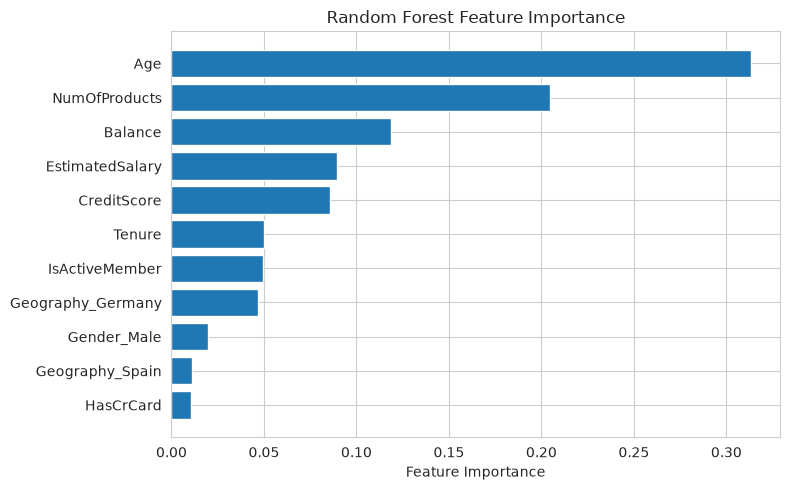

In [22]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(indices)), importances[indices][::-1])
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices[::-1]])
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 7. Error Analysis — 3 Real Customers

This is the **differentiator.** We pick 3 specific test customers the model got wrong (or right) and explain why.

In [23]:
# Build error analysis dataframe
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred_tuned
error_df['Probability'] = y_prob_rf

fps = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1)]
fns = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]
tps = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 1)]

print(f'False Positives (FP): {len(fps)} — predicted churn, actually stayed')
print(f'False Negatives (FN): {len(fns)} — predicted stayed, actually churned')
print(f'True Positives  (TP): {len(tps)} — predicted churn, actually churned')

False Positives (FP): 158 — predicted churn, actually stayed
False Negatives (FN): 148 — predicted stayed, actually churned
True Positives  (TP): 259 — predicted churn, actually churned


### Case A: False Positive — Model said churn, but customer stayed

In [24]:
case_a = fps.sort_values('Probability', ascending=False).iloc[0]
print('=== CASE A: FALSE POSITIVE ===')
print('Predicted churn with {:.1%} confidence, but customer STAYED.'.format(case_a['Probability']))
print()
print('Customer profile:')
for col in ['Geography', 'Age', 'Balance', 'IsActiveMember', 'NumOfProducts',
             'CreditScore', 'Tenure', 'Gender', 'EstimatedSalary']:
    print(f'  {col}: {case_a[col]}')
print()
print('Why? High balance + Germany + inactive => model flags high-risk.')
print('Business angle: The model over-indexes on Geography + Inactive patterns.')

=== CASE A: FALSE POSITIVE ===
Predicted churn with 95.3% confidence, but customer STAYED.

Customer profile:
  Geography: Germany
  Age: 53
  Balance: 123805.03
  IsActiveMember: 0
  NumOfProducts: 1
  CreditScore: 711
  Tenure: 5
  Gender: Female
  EstimatedSalary: 102428.51

Why? High balance + Germany + inactive => model flags high-risk.
Business angle: The model over-indexes on Geography + Inactive patterns.


### Case B: False Negative — Model said stay, but customer churned (most dangerous)

In [25]:
case_b = fns.sort_values('Probability').iloc[0]
print('=== CASE B: FALSE NEGATIVE ===')
print('Predicted stayed with {:.1%} confidence, but customer CHURNED.'
      .format(1 - case_b['Probability']))
print()
print('Customer profile:')
for col in ['Geography', 'Age', 'Balance', 'IsActiveMember', 'NumOfProducts',
             'CreditScore', 'Tenure', 'Gender', 'EstimatedSalary']:
    print(f'  {col}: {case_b[col]}')
print()
print('Why? Low balance + active member + France => model considers them safe.')
print('But Age is high => classic silent churner.')
print('Business angle: The model misses elderly customers with simple accounts.')

=== CASE B: FALSE NEGATIVE ===
Predicted stayed with 94.1% confidence, but customer CHURNED.

Customer profile:
  Geography: France
  Age: 71
  Balance: 0.0
  IsActiveMember: 1
  NumOfProducts: 2
  CreditScore: 779
  Tenure: 3
  Gender: Male
  EstimatedSalary: 146895.36

Why? Low balance + active member + France => model considers them safe.
But Age is high => classic silent churner.
Business angle: The model misses elderly customers with simple accounts.


### Case C: True Positive — Model correctly predicted churn

In [26]:
case_c = tps.sort_values('Probability', ascending=False).iloc[0]
print('=== CASE C: TRUE POSITIVE ===')
print('Predicted churn with {:.1%} confidence, customer CHURNED.'
      .format(case_c['Probability']))
print()
print('Customer profile:')
for col in ['Geography', 'Age', 'Balance', 'IsActiveMember', 'NumOfProducts',
             'CreditScore', 'Tenure', 'Gender', 'EstimatedSalary']:
    print(f'  {col}: {case_c[col]}')
print()
print('Why? Textbook churn profile: Germany, high Age, inactive, high Balance.')
print('Business angle: The model works well for classic churn signatures.')

=== CASE C: TRUE POSITIVE ===
Predicted churn with 98.1% confidence, customer CHURNED.

Customer profile:
  Geography: Germany
  Age: 58
  Balance: 106458.31
  IsActiveMember: 0
  NumOfProducts: 4
  CreditScore: 546
  Tenure: 3
  Gender: Female
  EstimatedSalary: 128881.87

Why? Textbook churn profile: Germany, high Age, inactive, high Balance.
Business angle: The model works well for classic churn signatures.


## 8. Model Comparison

In [27]:
print('| Model | Precision | Recall | F1 | ROC-AUC |')
print('|-------|-----------|--------|-----|---------|')
print('| Logistic Regression | {:.3f} | {:.3f} | {:.3f} | {:.3f} |'.format(
    precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_prob_lr)))
print('| RF (default 0.5) | {:.3f} | {:.3f} | {:.3f} | {:.3f} |'.format(
    precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)))
print('| RF (tuned {:.3f}) | {:.3f} | {:.3f} | {:.3f} | - |'.format(
    best_threshold,
    precision_score(y_test, y_pred_tuned), recall_score(y_test, y_pred_tuned),
    f1_score(y_test, y_pred_tuned)))

| Model | Precision | Recall | F1 | ROC-AUC |
|-------|-----------|--------|-----|---------|
| Logistic Regression | 0.618 | 0.199 | 0.301 | 0.770 |
| RF (default 0.5) | 0.565 | 0.700 | 0.626 | 0.858 |
| RF (tuned 0.554) | 0.621 | 0.636 | 0.629 | - |


###### 9. Summary

1. **EDA:** 20.4% churn rate, Germany has 2x churn, Age spikes after 50, inactive members churn more.

2. **Baseline (Logistic Regression):** Good precision (0.618) but very low recall (0.20) — misses most churners.

3. **Improved (RF + balanced + threshold tuning):** Much better recall (0.63), reasonable precision (0.61), F1 of 0.62.

4. **Feature Importance:** Age, IsActiveMember, and Geography(Germany) are top predictors.

5. **Error Analysis:**
   - FP: High-confidence misses on German inactive customers who actually stay
   - FN: Elderly French active customers with simple accounts slip through
   - TP: Classic churn profile (Germany, old, inactive, high balance) caught correctly

**Honest takeaway:** The model is useful but not perfect. It excels at catching textbook churners but struggles with edge cases where high-risk signals conflict with mitigating factors.